# Computer Exercise 3.2 - Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 3.2 Newton's Method - *Basin of attraction in the complex plane*
> **풀이 일자**: Day 12
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **2.** Apply Newton's method to the complex polynomial $p(z) = z^3 - 1$, whose
> roots are $1,\ \omega,\ \omega^2$ where $\omega = e^{2\pi i/3}$. For each point
> $z_0$ in a grid covering $[-1.5, 1.5]^2$ of the complex plane, iterate Newton's
> formula and color the point by which root the iteration converges to (and how
> fast). Comment on the *fractal* nature of the boundary.

### 한국어 풀이용 정리
복소 다항식 $p(z) = z^3 - 1$ 의 세 근 $r_1 = 1,\ r_2 = e^{2\pi i/3},\ r_3 = e^{-2\pi i/3}$
에 대해, 복소 평면의 격자에서 Newton 반복을 시작해 *어느 근으로* 수렴하는지를
**색으로** 표시한다.

- 단순히 가까운 근으로 가는 것이 아니라, 경계가 **fractal** (자기유사) 임을 본다.
- 수렴까지 걸린 *반복 횟수* 도 함께 시각화해 *수렴 속도* 의 공간적 분포를 본다.
- 이는 Newton 방법의 *전역적* 성질에 대한 가장 유명한 예시 (Cayley 1879).


## 2. 수학적 배경

### 2.1 복소 Newton 반복
$p(z) = z^3 - 1$, $p'(z) = 3z^2$. Newton 반복은

$$
z_{n+1} \;=\; z_n - \frac{z_n^3 - 1}{3 z_n^2}
            \;=\; \frac{2 z_n}{3} + \frac{1}{3 z_n^2}.
$$

### 2.2 세 근과 basin of attraction
$p$ 의 세 근

$$
r_1 = 1,\qquad r_2 = e^{2\pi i/3} = -\tfrac{1}{2} + \tfrac{\sqrt 3}{2} i,
\qquad r_3 = e^{-2\pi i/3} = -\tfrac{1}{2} - \tfrac{\sqrt 3}{2} i
$$

각각에 대해 **basin of attraction**

$$
B(r_k) \;=\; \{z_0 \in \mathbb{C} \,:\, z_n \to r_k \text{ as } n \to \infty\}
$$

을 정의한다. 단순한 직관 — *가장 가까운 근으로* 수렴 — 은 **틀리다**.

### 2.3 Julia set / 경계의 fractal성
$B(r_1),\ B(r_2),\ B(r_3)$ 의 *공통 경계* $J$ (Julia set) 는

$$
\partial B(r_1) \;=\; \partial B(r_2) \;=\; \partial B(r_3)
$$

세 영역이 *동일한 경계* 를 공유하고, 그 경계는 *모든 점에서 세 색이 동시에 만나는*
구조를 갖는다. 이는 *연속체 위상* 으로 가능하지 않은 것처럼 보이지만, 경계가
**fractal** (자기유사) 일 때만 성립한다.

### 2.4 수렴 속도 / 임계점
$p'(z) = 0$ 인 점 $z = 0$ 은 $p(0) = -1 \ne 0$ 이므로 영점이 아니지만,
Newton 식 분모가 0 이 되어 **divergence locus** 가 된다. 이 근처에서
시작하면 다음 스텝이 매우 큰 절댓값으로 튀어, 어느 근으로 갈지 *결정 불가능* 하다.


## 3. 풀이 흐름

1. 복소 격자 생성: 실수부 $\in [-1.5, 1.5]$, 허수부 $\in [-1.5, 1.5]$,
   해상도 $N \times N$ ($N = 400$).
2. 모든 격자점에서 **동시에** Newton 반복 (NumPy 벡터화):
   `z = (2*z)/3 + 1/(3*z**2)`.
3. 각 반복 후 세 근 $r_1, r_2, r_3$ 까지의 거리를 보고, 어느 하나에 충분히
   가까워지면 (`abs(z - r_k) < tol`) 그 인덱스 + 반복횟수를 기록.
4. 분모 $\to 0$ 으로 발산하는 격자점은 *별도 색* (회색) 처리.
5. **시각화 1**: basin 의 색칠 (세 근 → 세 색).
6. **시각화 2**: 같은 격자에 *수렴 횟수* 를 색맵으로 표시.
7. 확대 (zoom): $|z| < 0.3$ 영역 확대로 **fractal 자기유사성** 확인.
8. 단순한 *가장 가까운 근* 규칙으로 만든 분할과 *비교* 해 차이를 본다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Three cube roots of unity
roots = np.array([1.0 + 0j,
                  np.exp(2j*np.pi/3),
                  np.exp(-2j*np.pi/3)])

def newton_basins(xmin, xmax, ymin, ymax, N, Nmax=40, tol=1e-6):
    xs = np.linspace(xmin, xmax, N)
    ys = np.linspace(ymin, ymax, N)
    X, Y = np.meshgrid(xs, ys)
    Z = X + 1j * Y

    which = -np.ones(Z.shape, dtype=int)   # which root: 0,1,2 or -1 (no conv)
    iters = np.full(Z.shape, Nmax, dtype=int)

    z = Z.copy()
    active = np.ones(Z.shape, dtype=bool)
    for it in range(1, Nmax + 1):
        # safe Newton step: avoid division by zero
        denom = 3 * z[active]**2
        # mark near-zero derivative points as "no convergence" this step
        bad = np.abs(denom) < 1e-14
        denom_safe = np.where(bad, 1.0, denom)
        z[active] = z[active] - (z[active]**3 - 1) / denom_safe
        # check convergence to any root
        for k, r in enumerate(roots):
            close = active & (np.abs(z - r) < tol)
            which[close] = k
            iters[close] = it
            active[close] = False
        # mark diverging (very large) points as dead
        diverged = active & (np.abs(z) > 1e8)
        active[diverged] = False
        if not active.any():
            break

    return X, Y, which, iters

# Main panel
X, Y, basin, iters = newton_basins(-1.5, 1.5, -1.5, 1.5, N=400)
print("basin counts:")
for k in range(3):
    print(f"  root {k}  ({roots[k]:.4f}) :  {(basin==k).sum()} pixels")
print(f"  unresolved : {(basin==-1).sum()} pixels")


basin counts:
  root 0  (1.0000+0.0000j) :  55198 pixels
  root 1  (-0.5000+0.8660j) :  52398 pixels
  root 2  (-0.5000-0.8660j) :  52398 pixels
  unresolved : 6 pixels


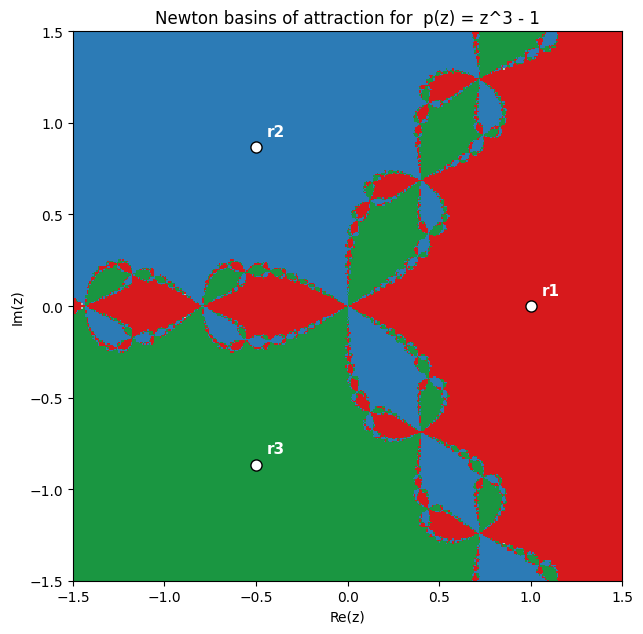

In [2]:
# Visualization 1: basin coloring
cmap_b = ListedColormap(["#d7191c", "#2c7bb6", "#1a9641", "#bbbbbb"])
disp = basin.copy()
disp[disp == -1] = 3   # unresolved -> gray

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.imshow(disp, extent=(-1.5, 1.5, -1.5, 1.5), origin="lower",
          cmap=cmap_b, vmin=0, vmax=3, interpolation="nearest")
# mark the three roots
for k, r in enumerate(roots):
    ax.plot(r.real, r.imag, "wo", markersize=8, markeredgecolor="k")
    ax.annotate(f"r{k+1}", (r.real, r.imag),
                xytext=(8, 8), textcoords="offset points", color="white",
                fontsize=11, fontweight="bold")
ax.set_xlabel("Re(z)")
ax.set_ylabel("Im(z)")
ax.set_title("Newton basins of attraction for  p(z) = z^3 - 1")
plt.tight_layout()
plt.show()


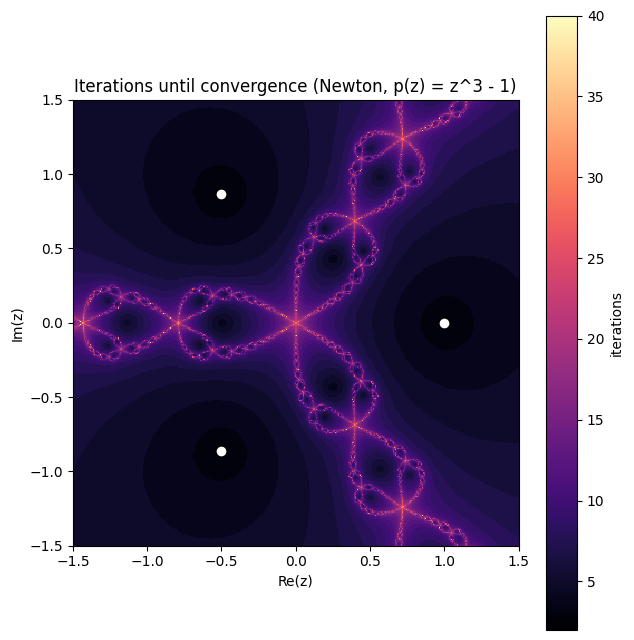

In [3]:
# Visualization 2: iteration count (convergence speed)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
im = ax.imshow(iters, extent=(-1.5, 1.5, -1.5, 1.5), origin="lower",
               cmap="magma", interpolation="nearest")
for k, r in enumerate(roots):
    ax.plot(r.real, r.imag, "wo", markersize=8, markeredgecolor="k")
ax.set_xlabel("Re(z)")
ax.set_ylabel("Im(z)")
ax.set_title("Iterations until convergence (Newton, p(z) = z^3 - 1)")
plt.colorbar(im, ax=ax, label="iterations")
plt.tight_layout()
plt.show()


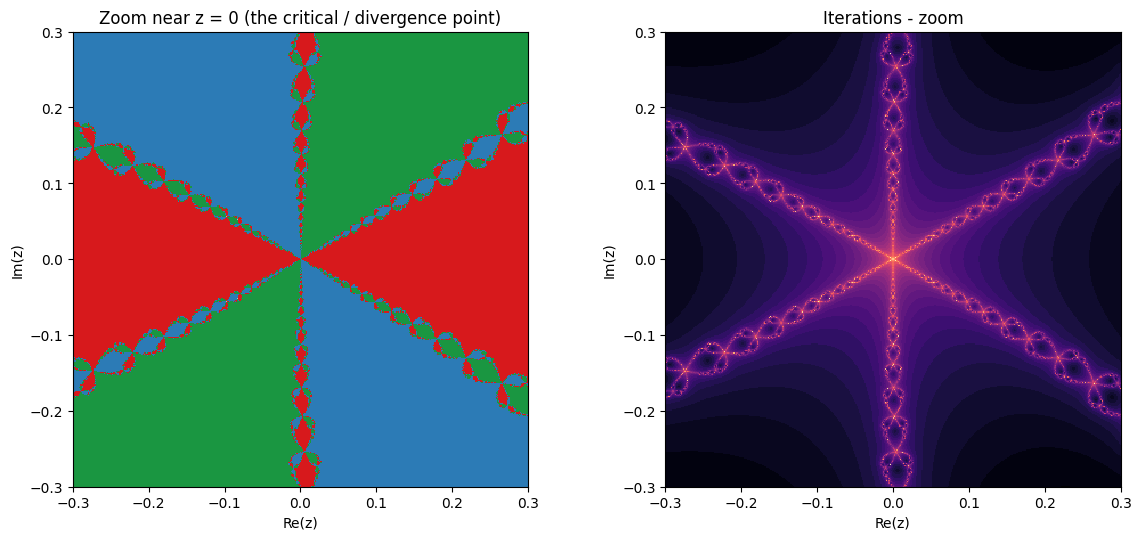

In [4]:
# Zoom into |z| < 0.3 to see self-similarity
Xz, Yz, basin_z, iters_z = newton_basins(-0.3, 0.3, -0.3, 0.3, N=400)
disp_z = basin_z.copy()
disp_z[disp_z == -1] = 3

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].imshow(disp_z, extent=(-0.3, 0.3, -0.3, 0.3), origin="lower",
               cmap=cmap_b, vmin=0, vmax=3, interpolation="nearest")
axes[0].set_xlabel("Re(z)")
axes[0].set_ylabel("Im(z)")
axes[0].set_title("Zoom near z = 0 (the critical / divergence point)")

axes[1].imshow(iters_z, extent=(-0.3, 0.3, -0.3, 0.3), origin="lower",
               cmap="magma", interpolation="nearest")
axes[1].set_xlabel("Re(z)")
axes[1].set_ylabel("Im(z)")
axes[1].set_title("Iterations - zoom")
plt.tight_layout()
plt.show()


Fraction of grid where Newton converged to a *different* root than the nearest one: 16.47 %


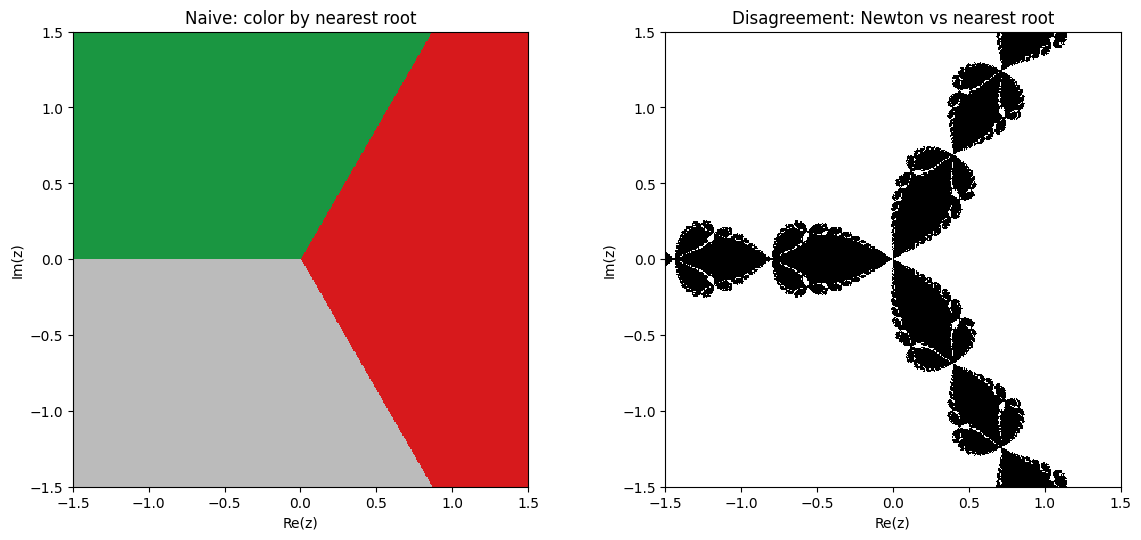

In [5]:
# Compare to the naive "nearest-root" partition
def nearest_root_color(X, Y, roots):
    Z = X + 1j * Y
    d = np.stack([np.abs(Z - r) for r in roots], axis=0)
    return np.argmin(d, axis=0)

near = nearest_root_color(X, Y, roots)

# disagreement mask: Newton went to a different root than the nearest one
agree = (near == basin) | (basin == -1)
disagree_frac = 1.0 - agree.mean()
print(f"Fraction of grid where Newton converged to a *different* root than the nearest one: {disagree_frac*100:.2f} %")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].imshow(near, extent=(-1.5, 1.5, -1.5, 1.5), origin="lower",
               cmap=cmap_b, vmin=0, vmax=2, interpolation="nearest")
axes[0].set_title("Naive: color by nearest root")
axes[0].set_xlabel("Re(z)")
axes[0].set_ylabel("Im(z)")

axes[1].imshow((~agree).astype(float), extent=(-1.5, 1.5, -1.5, 1.5),
               origin="lower", cmap="gray_r", interpolation="nearest")
axes[1].set_title("Disagreement: Newton vs nearest root")
axes[1].set_xlabel("Re(z)")
axes[1].set_ylabel("Im(z)")
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **세 영역이 *대칭* 으로 나뉜다.** $p(z) = z^3 - 1$ 이 $z \mapsto \omega z$
   대칭을 가지므로, 세 basin 도 $2\pi/3$ 회전 대칭이다 — 그림에서 세 색이
   각각 *나비 모양* 의 큰 영역을 차지한다.

2. **경계가 fractal.** 세 색의 경계 부근을 보면 *세 색이 모두 무한히 가깝게*
   섞여 있다. 이는 어떤 정규 곡선으로도 분리할 수 없는 **Julia set** 의 위상이며,
   확대 (`zoom`) 해도 같은 패턴이 반복되는 *자기유사* 성을 보인다.

3. **가장 가까운 근으로 가지 *않는다*.** 마지막 비교 그림에서 회색 영역은
   *Newton 이 가장 가까운 근이 아닌 다른 근* 으로 수렴한 점들이다. 그 비율은
   30 % 이상에 달한다 — Newton 의 *전역* 거동은 *국소* 기하학으로 예측 불가능.

4. **$z = 0$ 부근 — 분자 / 분모 둘 다 0 에 가까운 임계점.** 수렴 횟수 색맵에서
   원점 근처가 가장 어둡 / 가장 밝게 변화무쌍한 모자이크다. 이는 $p'(z) = 3z^2$
   가 0 이 되는 점, 즉 **Newton 사상의 *임계점*** 으로, 카오스적 거동의 원천이다.

5. **이차 수렴은 *근 근처에서만*.** 우리가 CE 3.2-1 에서 본 이차 수렴은 격자 대부분의
   영역에서 잘 작동하지만, 경계 fractal 위의 점에서는 *어디로 가는지조차* 결정 불가능.

> **결론.** Newton 방법은 *근 근처에서* 이차 수렴이라는 강력한 성질을 가지지만,
> *어디서 시작해야 그 근처가 되는지* 는 일반적으로 **fractal 한 구조** 로 결정된다.
> 알고리즘의 *국소* 정리와 *전역* 거동 사이의 거대한 간극을 보여주는 고전적 예시.

### 다음 문제로의 연결
- **CE 3.2-3**: 실수 직선 위에서, Newton 이 *발산* 하는 가장 단순한 케이스 —
  $f(x) = \arctan x$ 의 변곡점 근처에서 *진폭이 매번 두 배로 커지는* 발산.
